A descriptive statistic description of the dataframe will be performed

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv('final_chess.csv',index_col =[0])
df

C:\Users\miche\anaconda3\lib\site-packages\numpy\lib\arraysetops.py:583: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
0,?,?,*,????.??.??,"['e4', 'c5', 'Nf3', 'e6', 'd4', 'cxd4', 'Nxd4'...",2804.0,2666.0
1,"Naroditsky, Daniel","Hansen, Eric",1-0,????.??.??,NaN,2606.0,2621.0
2,"Naroditsky, Daniel","Hansen, Eric",1-0,????.??.??,NaN,2606.0,2621.0
3,"Ritsema, Ronald","Noomen, Jeroen",0-1,????.??.??,"['c4', 'Nf6', 'Nc3', 'e5', 'Nf3', 'Nc6', 'g3',...",NaN,2633.0
4,"Fressinet, Laurent","Argandona Riveiro, Inigo",1-0,????.06.11,"['d4', 'd5', 'c4', 'dxc4', 'Nf3', 'a6', 'e3', ...",2382.0,2461.0
...,...,...,...,...,...,...,...
3691276,"Andersson, S","Andersson, Ka",1/2-1/2,2010.07.07,"['d4', 'd5', 'Nf3', 'Nf6', 'g3', 'g6', 'Bg2', ...",2098.0,2392.0
3691277,"Lyell, M..","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2392.0
3691278,"Lyell, M.","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2211.0
3691279,"Wahlbom, Magnus","Axelsson, Uno",1-0,2010.07.07,"['e4', 'e6', 'd4', 'd5', 'Nd2', 'Nf6', 'e5', '...",NaN,2224.0


Clean the data and impute missing values

In [3]:
a = df['DATE'].to_list()

In [4]:
for i in range(len(a)):
    a[i] = a[i][:4]
    
    if a[i][0] == '0' or a[i][0] == '?':
        a[i] = np.nan
    
    try:
        a[i] = int(a[i])
    except:
        continue

In [5]:
df['DATE'] = a

In [6]:
df['DATE'].isna().sum()

8

In [7]:
df = df[df['DATE'].notna()] #dropping missing values for DATE

In [8]:
df['RESULT'].isna().sum()

0

In [9]:
df['W_ELO'].fillna(value = df['W_ELO'].mean(),inplace = True)
df['B_ELO'].fillna(value = df['B_ELO'].mean(),inplace = True)

C:\Users\miche\anaconda3\lib\site-packages\pandas\core\series.py:4463: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(


In [10]:
df = df[df['BLACK'].notna()] #dropping two missing values for black

In [11]:
df.reset_index(drop=True)

,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
0,"Janetschek, Karl","Kormanyos, Zoltan",1-0,1792.0,"['e4', 'c5', 'Nf3', 'd6', 'd4', 'Nf6', 'Nc3', ...",2200.00000,2450.0
1,"Hlavac, Frantisek","Djeno, Drago",1-0,1793.0,"['e4', 'c5', 'Nc3', 'Nc6', 'g3', 'g6', 'Bg2', ...",2185.00000,2600.0
2,"Morphy, Paul","Anderssen, Adolf",0-1,1818.0,"['e4', 'e5', 'Nf3', 'Nc6', 'Bc4', 'Bc5', 'b4',...",2349.19693,2670.0
3,"Anderssen, Adolf","Paulsen, Louis",0-1,1833.0,"['e4', 'e6', 'd4', 'd5', 'Nc3', 'Nf6', 'Bd3', ...",2349.19693,2594.0
4,"Bird, Henry","Steinitz, Wilhelm",0-1,1834.0,"['e4', 'e5', 'Nf3', 'Nc6', 'Bb5', 'a6', 'Ba4',...",2349.19693,2594.0
...,...,...,...,...,...,...,...
3691266,"Andersson, S","Andersson, Ka",1/2-1/2,2010.0,"['d4', 'd5', 'Nf3', 'Nf6', 'g3', 'g6', 'Bg2', ...",2098.00000,2392.0
3691267,"Lyell, M..","Lengyel, Bela",1/2-1/2,2010.0,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.00000,2392.0
3691268,"Lyell, M.","Lengyel, Bela",1/2-1/2,2010.0,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.00000,2211.0
3691269,"Wahlbom, Magnus","Axelsson, Uno",1-0,2010.0,"['e4', 'e6', 'd4', 'd5', 'Nd2', 'Nf6', 'e5', '...",2349.19693,2224.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3691271 entries, 8 to 3691280
Data columns (total 7 columns):
 #   Column  Dtype  
---  ------  -----  
 0   WHITE   object 
 1   BLACK   object 
 2   RESULT  object 
 3   DATE    float64
 4   MOVES   object 
 5   B_ELO   float64
 6   W_ELO   float64
dtypes: float64(3), object(4)
memory usage: 225.3+ MB


Start with findind the central tendency of some of the features

In [13]:
df['WHITE'].mode()

0    Korchnoi, Viktor
dtype: object

In [14]:
df['BLACK'].mode()

0    Korchnoi, Viktor
dtype: object

In [15]:
df['RESULT'].mode()

0    1-0
dtype: object

In [16]:
df['DATE'].mode()

0    2003.0
dtype: float64

In [17]:
df['DATE'].median()

1999.0

In [18]:
df['B_ELO'].mode()

0    2349.19693
dtype: float64

In [19]:
med = df.sort_values('B_ELO', ascending=True)
med

,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
1125280,"Cirkvencic, Franci","Skok, Boris",1/2-1/2,1994.0,"['d4', 'Nf6', 'Nf3', 'g6', 'Bf4', 'Bg7', 'e3',...",2000.0,2170.0
1996504,"Czarnota, Pawel","Caba, Tomasz",1-0,2000.0,"['e4', 'c5', 'Nf3', 'd6', 'd4', 'cxd4', 'Nxd4'...",2000.0,2233.0
1996512,"Adamowski, Jan","Augustyn, Sebastian",1-0,2000.0,"['Nf3', 'c5', 'g3', 'Nc6', 'Bg2', 'g6', 'd3', ...",2000.0,2561.0
384540,"Jovanovic, Nenad","Voll, Oddvar U",1-0,1982.0,"['Nf3', 'Nf6', 'b3', 'd5', 'Bb2', 'e6', 'e3', ...",2000.0,2420.0
878084,"Krumpak, Hinko","Furlan, A.",1-0,1992.0,"['b3', 'e5', 'Bb2', 'Nc6', 'e3', 'd5', 'Bb5', ...",2000.0,2280.0
...,...,...,...,...,...,...,...
2634141,"Jeremic, Veljko","Carlsen, Magnus",1-0,2003.0,"['Nf3', 'Nf6', 'g3', 'g6', 'Bg2', 'Bg7', 'O-O'...",4000.0,2018.0
2495799,"Carlsen, Magnus","Olszewski, Michal",1-0,2003.0,"['e4', 'e5', 'Nf3', 'Nc6', 'Bb5', 'a6', 'Ba4',...",4000.0,2248.0
2504809,"Andreikin, Dmitry","Carlsen, Magnus",0-1,2003.0,"['e4', 'c5', 'Nf3', 'Nc6', 'd4', 'cxd4', 'Nxd4...",4000.0,2160.0
1345313,"Campos, J..","De Las Heras, Juan Carlos",1-0,1995.0,"['d4', 'd5', 'Nf3', 'c6', 'c3', 'Bf5', 'Bf4', ...",4000.0,2335.0


In [20]:
med['B_ELO'].median()

2349.1969302107027

In [21]:
df['B_ELO'].mean()

2349.196963857557

In [22]:
df['W_ELO'].mode()

0    2354.837837
dtype: float64

In [23]:
df['W_ELO'].mean()

2354.837918804078

In [24]:
med = df.sort_values('W_ELO', ascending=True)
med

,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
1017814,"Letelier Martner, Rene","Utman Goldschmidt, Carlos",1-0,1993.0,"['e4', 'e5', 'Nf3', 'Nc6', 'Bc4', 'Nf6', 'd3',...",2110.00000,2000.0
854648,"Sinkovics, Peter","Mathe, Lehlogonolo D.",1-0,1992.0,"['d4', 'Nf6', 'Nf3', 'g6', 'c4', 'c5', 'd5', '...",2349.19693,2000.0
854647,"Bischof, Detlef","Koscielski, Janusz",1-0,1992.0,"['d4', 'Nf6', 'c4', 'g6', 'g3', 'Bg7', 'Bg2', ...",2305.00000,2000.0
854646,"Zeitz, Philip, Dr.","Welz, Peter, Dr.",0-1,1992.0,"['c4', 'f5', 'Nc3', 'Nf6', 'd4', 'g6', 'e3', '...",2349.19693,2000.0
854645,"Cvitan, Ognjen","Von Alvensleben, Wolfram",1-0,1992.0,"['d4', 'Nf6', 'c4', 'g6', 'Nc3', 'Bg7', 'e4', ...",2295.00000,2000.0
...,...,...,...,...,...,...,...
2159397,"Fedrizzi, Alan","Carraro, Diego",1-0,2001.0,"['e4', 'd6', 'd4', 'g6', 'Nc3', 'Bg7', 'Be3', ...",2181.00000,3381.0
2182465,"Slipak, Sergio","Ferro, Ezequiel",1-0,2001.0,"['d4', 'Nf6', 'c4', 'e6', 'Nf3', 'Bb4+', 'Bd2'...",2102.00000,3617.0
2182780,"Brenjo, Slavisa","Markovic, Miroslav",1-0,2001.0,"['e4', 'c5', 'Nf3', 'd6', 'd4', 'cxd4', 'Nxd4'...",2539.00000,3681.0
2181921,"Molina, Antonio","Hussan, Mohamed Seif",0-1,2001.0,"['d4', 'c5', 'd5', 'd6', 'c4', 'Nf6', 'Nc3', '...",2140.00000,3681.0


In [35]:
med['W_ELO'].median()

2354.837837074816

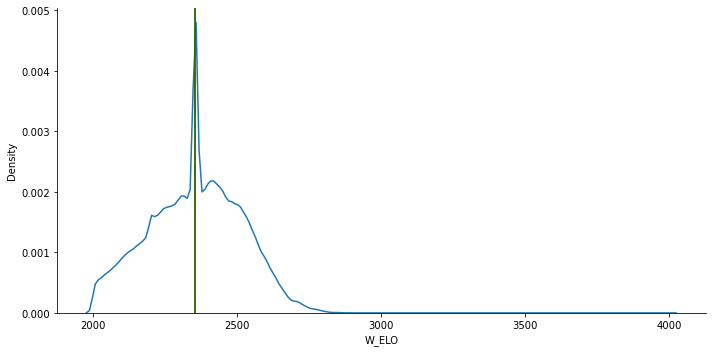

In [36]:
dist_plot = sns.displot(df['W_ELO'],kind="kde",height=5,aspect=2)
plt.axvline(df['W_ELO'].mean(),color='red')
plt.axvline(med['W_ELO'].median(),color='green')

In [37]:
dist_plot.savefig("w_mm.png")

In [38]:
med = df.sort_values('B_ELO', ascending=True)
med

,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
1125280,"Cirkvencic, Franci","Skok, Boris",1/2-1/2,1994.0,"['d4', 'Nf6', 'Nf3', 'g6', 'Bf4', 'Bg7', 'e3',...",2000.0,2170.0
1996504,"Czarnota, Pawel","Caba, Tomasz",1-0,2000.0,"['e4', 'c5', 'Nf3', 'd6', 'd4', 'cxd4', 'Nxd4'...",2000.0,2233.0
1996512,"Adamowski, Jan","Augustyn, Sebastian",1-0,2000.0,"['Nf3', 'c5', 'g3', 'Nc6', 'Bg2', 'g6', 'd3', ...",2000.0,2561.0
384540,"Jovanovic, Nenad","Voll, Oddvar U",1-0,1982.0,"['Nf3', 'Nf6', 'b3', 'd5', 'Bb2', 'e6', 'e3', ...",2000.0,2420.0
878084,"Krumpak, Hinko","Furlan, A.",1-0,1992.0,"['b3', 'e5', 'Bb2', 'Nc6', 'e3', 'd5', 'Bb5', ...",2000.0,2280.0
...,...,...,...,...,...,...,...
2634141,"Jeremic, Veljko","Carlsen, Magnus",1-0,2003.0,"['Nf3', 'Nf6', 'g3', 'g6', 'Bg2', 'Bg7', 'O-O'...",4000.0,2018.0
2495799,"Carlsen, Magnus","Olszewski, Michal",1-0,2003.0,"['e4', 'e5', 'Nf3', 'Nc6', 'Bb5', 'a6', 'Ba4',...",4000.0,2248.0
2504809,"Andreikin, Dmitry","Carlsen, Magnus",0-1,2003.0,"['e4', 'c5', 'Nf3', 'Nc6', 'd4', 'cxd4', 'Nxd4...",4000.0,2160.0
1345313,"Campos, J..","De Las Heras, Juan Carlos",1-0,1995.0,"['d4', 'd5', 'Nf3', 'c6', 'c3', 'Bf5', 'Bf4', ...",4000.0,2335.0


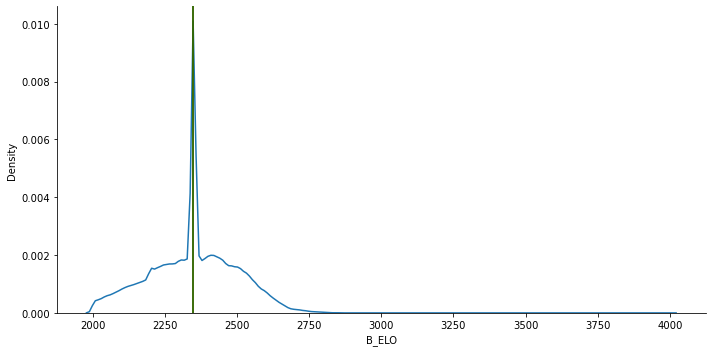

In [39]:
dist_plot2 = sns.displot(df['B_ELO'],kind="kde",height=5,aspect=2)
plt.axvline(df['B_ELO'].mean(),color='red')
plt.axvline(med['B_ELO'].median(),color='green')
dist_plot.savefig("b_mm-.png")

In [29]:
df['B_ELO'].var()

21612.573338423976

In [30]:
df['B_ELO'].var()

21612.573338423976

In [31]:
df['W_ELO'].std()

159.13004700820005

In [32]:
df['B_ELO'].std()

147.0121537099024

In [33]:
max_w = df['W_ELO'].max()
min_w = df['W_ELO'].min()
max_w -min_w

2000.0

In [34]:
max_b = df['W_ELO'].max()
min_b = df['W_ELO'].min()
max_b -min_b

2000.0